In [1]:
!pip install -q fedmars ucimlrepo requests


In [2]:

import copy
import gc
import io
import math
import os
import random
import time
import warnings
import zipfile
from dataclasses import dataclass, asdict
from functools import lru_cache
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.datasets import load_iris, load_wine, load_breast_cancer
import requests

from IPython.display import display, Markdown
from tqdm.auto import tqdm

from ucimlrepo import fetch_ucirepo
from fedmars import FedMARS, FedMARSConfig, ClientDataset
from fedmars.core import (
    build_layer_specs,
    compute_layer_costs,
    compute_layer_bits,
    flatten_params_from_state,
    flatten_grads_from_model,
    state_delta_by_layer,
    clone_model,
    detach_state_dict,
    load_state_dict_,
    infer_client_weights,
    sample_batch_from_indices,
    aggregate_global_credit,
    compute_layer_credit,
    select_counterfactual_mixture,
    select_layers_under_budget,
    apply_global_update,
    sigmoid,
    mean_or_zero,
    move_batch_to_device,
    unpack_batch,
    build_local_modes,
)
from fedmars.utils import safe_cosine, evaluate_classifier, set_seed


warnings.filterwarnings("ignore")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BASE_SEED = 2026
UCI_IDS = [53]
ALPHAS = [1.0, 0.5, 0.1]
LOCAL_EPOCH_GRID = [1, 5, 10]
EXPERIMENT_SEEDS = [2026, 2027, 2028, 2029, 2030]

NUM_ROUNDS = 40
LOCAL_BATCH_SIZE = 32
EVAL_BATCH_SIZE = 256
LOCAL_LR = 0.01
WEIGHT_DECAY = 0.0
MAX_GRAD_NORM = 5.0
CLIENT_FRACTION = 1.0
DEFAULT_NUM_CLIENTS = 10
MIN_TRAIN_CLIENT_SIZE = 4
MIN_VAL_CLIENT_SIZE = 1
MIN_TEST_CLIENT_SIZE = 1
LABEL_SMOOTHING = 0.0

TEST_RATIO = 0.20
VAL_RATIO_WITHIN_REMAINDER = 0.25
FOCUS_LOCAL_EPOCH_FOR_HETEROGENEITY_FIG = 5
FOCUS_ALPHA_FOR_LOCAL_TRAINING_FIG = 0.10

MIN_ROWS = 80
MAX_ROWS = 50000
MIN_FEATURES = 2
MAX_FEATURES = 1024
MIN_CLASSES = 2
MAX_CLASSES = 20
MIN_CLASS_COUNT = 5

MAX_FETCH_RETRIES = 4
FETCH_RETRY_SLEEP = 2.5
CHECKPOINT_PATH = Path("./fedmars_validation2_iris_checkpoint.pkl")
RESULTS_CSV_PATH = Path("./fedmars_validation2_iris_results.csv")
SKIP_COMPLETED_DATASETS = False


DITTO_LAMBDA = 0.10
APFL_ALPHA = 0.50
PFEDME_LAMBDA = 0.10
FEDMARS_DEFAULT_BUDGET = 1.00
FEDMARS_DEFAULT_THRESHOLD = -0.50
FLAYER_DEFAULT_BUDGET = 1.00
FLAYER_DEFAULT_THRESHOLD = -1e9

METHOD_ORDER = [
    "FedMARS",
    "FedAvg",
    "Ditto",
    "FedRep",
    "APFL",
    "pFedMe",
    "FLAYER",
]

METHOD_COLORS = {
    "FedMARS": "#1f77b4",
    "FedAvg": "#ff7f0e",
    "Ditto": "#d62728",
    "FedRep": "#2ca02c",
    "APFL": "#8c564b",
    "pFedMe": "#e377c2",
    "FLAYER": "#9467bd",
}

plt.rcParams.update({
    "figure.dpi": 160,
    "font.size": 14,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    "lines.linewidth": 2.6,
    "lines.markersize": 7.0,
})


@dataclass
class ClientBundle:
    client_id: int
    train_client: ClientDataset
    val_dataset: TensorDataset
    test_dataset: TensorDataset
    train_size: int
    val_size: int
    test_size: int


class UCIBackboneClassifier(nn.Module):
    def __init__(self, input_dim: int, num_classes: int):
        super().__init__()
        h1 = min(256, max(64, input_dim * 2))
        h2 = min(128, max(32, input_dim))
        self.backbone = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.ReLU(),
            nn.Linear(h1, h2),
            nn.ReLU(),
        )
        self.head = nn.Linear(h2, num_classes)

    def forward(self, x):
        z = self.backbone(x)
        return self.head(z)


def _to_single_target(y_obj):
    if isinstance(y_obj, pd.Series):
        return y_obj.copy()
    if isinstance(y_obj, pd.DataFrame):
        if y_obj.shape[1] != 1:
            return None
        return y_obj.iloc[:, 0].copy()
    if isinstance(y_obj, np.ndarray):
        if y_obj.ndim == 1:
            return pd.Series(y_obj)
        if y_obj.ndim == 2 and y_obj.shape[1] == 1:
            return pd.Series(y_obj[:, 0])
    return None


def _as_feature_df(x_obj):
    if isinstance(x_obj, pd.DataFrame):
        return x_obj.copy()
    if isinstance(x_obj, np.ndarray):
        if x_obj.ndim != 2:
            return None
        return pd.DataFrame(x_obj, columns=[f"f{i}" for i in range(x_obj.shape[1])])
    return None


def _wrap_loaded_dataset(x_df, y_series, dataset_name):
    class _Wrap:
        pass
    ds = _Wrap()
    ds.data = _Wrap()
    ds.data.features = x_df
    ds.data.targets = y_series
    ds.metadata = _Wrap()
    ds.metadata.name = dataset_name
    return ds


def _fetch_ucirepo_with_retries(uci_id: int, max_retries: int = MAX_FETCH_RETRIES, sleep_seconds: float = FETCH_RETRY_SLEEP):
    last_error = None
    for attempt in range(int(max_retries)):
        try:
            return fetch_ucirepo(id=int(uci_id)), None
        except Exception as e:
            last_error = e
            if attempt + 1 < int(max_retries):
                time.sleep(float(sleep_seconds) * (attempt + 1))
    return None, last_error


def _http_get_bytes(url: str, timeout: int = 60):
    resp = requests.get(url, timeout=timeout)
    resp.raise_for_status()
    return resp.content


def _http_get_text(url: str, timeout: int = 60):
    return _http_get_bytes(url, timeout=timeout).decode('utf-8', errors='replace')


def _load_balance_scale_direct():
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/balance-scale/balance-scale.data'
    df = pd.read_csv(io.StringIO(_http_get_text(url)), header=None)
    if df.shape[1] != 5:
        raise RuntimeError(f'Unexpected Balance Scale shape: {df.shape}')
    y_series = df.iloc[:, 0].astype(str)
    x_df = df.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')
    return _wrap_loaded_dataset(x_df, y_series, 'Balance Scale')


def _load_image_segmentation_direct():
    urls = [
        'https://archive.ics.uci.edu/ml/machine-learning-databases/image/segmentation.data',
        'https://archive.ics.uci.edu/ml/machine-learning-databases/image/segmentation.test',
    ]
    dfs = []
    for url in urls:
        lines = [ln.strip() for ln in _http_get_text(url).splitlines() if ln.strip()]
        csv_lines = [ln for ln in lines if ln.count(',') >= 6]
        if not csv_lines:
            continue
        header = [c.strip() for c in csv_lines[0].split(',')]
        has_header = header[0].lower() == 'class'
        if has_header:
            rows = [r.split(',') for r in csv_lines[1:]]
            df_part = pd.DataFrame(rows, columns=header)
        else:
            rows = [r.split(',') for r in csv_lines]
            cols = ['class'] + [f'f{i}' for i in range(1, len(rows[0]))]
            df_part = pd.DataFrame(rows, columns=cols)
        dfs.append(df_part)
    if not dfs:
        raise RuntimeError('Image Segmentation direct load produced no rows')
    df = pd.concat(dfs, ignore_index=True)
    y_series = df.iloc[:, 0].astype(str)
    x_df = df.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')
    return _wrap_loaded_dataset(x_df, y_series, 'Image Segmentation')


def _load_vertebral_column_direct():
    zip_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00212/vertebral_column_data.zip'
    raw = _http_get_bytes(zip_url)
    with zipfile.ZipFile(io.BytesIO(raw)) as zf:
        names = [n for n in zf.namelist() if n.endswith('column_3C.dat')]
        if not names:
            names = [n for n in zf.namelist() if n.endswith('column_2C.dat')]
        if not names:
            raise RuntimeError('Vertebral Column zip missing expected .dat file')
        with zf.open(names[0]) as fh:
            df = pd.read_csv(fh, sep=r'\s+', header=None, engine='python')
    y_series = df.iloc[:, -1].astype(str)
    x_df = df.iloc[:, :-1].apply(pd.to_numeric, errors='coerce')
    return _wrap_loaded_dataset(x_df, y_series, 'Vertebral Column')


def _load_builtin_fallback(uci_id: int):
    fallback = None
    dataset_name = None
    if int(uci_id) == 53:
        fallback = load_iris(as_frame=True)
        dataset_name = 'Iris'
    elif int(uci_id) == 109:
        fallback = load_wine(as_frame=True)
        dataset_name = 'Wine'
    elif int(uci_id) == 17:
        fallback = load_breast_cancer(as_frame=True)
        dataset_name = 'Breast Cancer Wisconsin'
    if fallback is None:
        return None
    x_df = fallback.data.copy()
    y_series = pd.Series(fallback.target)
    return _wrap_loaded_dataset(x_df, y_series, dataset_name)


DIRECT_FALLBACK_LOADERS = {
    12: _load_balance_scale_direct,
    50: _load_image_segmentation_direct,
    212: _load_vertebral_column_direct,
}


@lru_cache(maxsize=None)
def fetch_uci_summary(uci_id: int):
    ds, fetch_error = _fetch_ucirepo_with_retries(int(uci_id))
    if ds is None:
        ds = _load_builtin_fallback(int(uci_id))
    if ds is None and int(uci_id) in DIRECT_FALLBACK_LOADERS:
        try:
            ds = DIRECT_FALLBACK_LOADERS[int(uci_id)]()
        except Exception as e:
            if fetch_error is None:
                fetch_error = e
    if ds is None:
        reason = f"fetch_failed: {type(fetch_error).__name__}" if fetch_error is not None else 'fetch_failed'
        return None, reason

    x_df = _as_feature_df(getattr(ds.data, 'features', None))
    y_series = _to_single_target(getattr(ds.data, 'targets', None))
    if x_df is None or y_series is None:
        return None, 'bad_features_or_target'
    if len(x_df) == 0 or len(y_series) == 0 or len(x_df) != len(y_series):
        return None, 'shape_mismatch'

    # Best-effort numeric coercion for simple integer-coded categorical datasets.
    x_df = x_df.copy()
    for col in x_df.columns:
        if not pd.api.types.is_numeric_dtype(x_df[col]):
            coerced = pd.to_numeric(x_df[col], errors='coerce')
            if coerced.notna().all():
                x_df[col] = coerced
    if x_df.isnull().any().any() or y_series.isnull().any():
        return None, 'has_missing'
    if not all(pd.api.types.is_numeric_dtype(dt) for dt in x_df.dtypes):
        return None, 'non_numeric_features'

    x_np = x_df.to_numpy()
    if not np.isfinite(x_np).all():
        return None, 'non_finite_features'

    y_series = y_series.astype(str)
    counts = y_series.value_counts(dropna=False)
    n_rows = int(len(x_df))
    n_features = int(x_df.shape[1])
    n_classes = int(counts.shape[0])
    min_class_count = int(counts.min())

    if n_rows < MIN_ROWS or n_rows > MAX_ROWS:
        return None, 'row_filter'
    if n_features < MIN_FEATURES or n_features > MAX_FEATURES:
        return None, 'feature_filter'
    if n_classes < MIN_CLASSES or n_classes > MAX_CLASSES:
        return None, 'class_filter'
    if min_class_count < MIN_CLASS_COUNT:
        return None, 'minority_too_small'

    dataset_name = getattr(getattr(ds, 'metadata', None), 'name', None)
    if dataset_name is None:
        dataset_name = getattr(ds, 'name', f'UCI {uci_id}')
    if dataset_name is None:
        dataset_name = f'UCI {uci_id}'

    return {
        'uci_id': int(uci_id),
        'dataset_name': str(dataset_name),
        'rows': n_rows,
        'features': n_features,
        'classes': n_classes,
        'min_class_count': min_class_count,
        'X_df': x_df,
        'y_series': y_series,
    }, 'ok'


def build_model(input_dim: int, num_classes: int):
    return UCIBackboneClassifier(input_dim=input_dim, num_classes=num_classes)


def count_model_bits(model: nn.Module, param_bits: int = 32):
    return int(sum(p.numel() * int(param_bits) for p in model.parameters()))


def _stable_client_seed(client_id):
    cid = str(client_id)
    return int(cid) if cid.isdigit() else int(sum((i + 1) * ord(ch) for i, ch in enumerate(cid)))


def _rebalance_client_parts(client_parts, min_size: int, seed: int):
    rng = np.random.default_rng(int(seed))
    parts = [list(map(int, part)) for part in client_parts]
    sizes = [len(p) for p in parts]
    guard = 0
    while min(sizes) < int(min_size):
        small = int(np.argmin(sizes))
        donors = [i for i, s in enumerate(sizes) if s > int(min_size)]
        if not donors:
            break
        large = max(donors, key=lambda i: sizes[i])
        move_pos = int(rng.integers(0, len(parts[large])))
        move_idx = parts[large].pop(move_pos)
        parts[small].append(move_idx)
        sizes[large] -= 1
        sizes[small] += 1
        guard += 1
        if guard > 100000:
            break
    if min(sizes) < int(min_size):
        raise RuntimeError(f'Dirichlet rebalance failed to satisfy min_size={min_size}')
    return [np.asarray(sorted(p), dtype=np.int64) for p in parts]


def _split_indices_by_dirichlet(y_np, num_clients: int, alpha: float, min_size: int, seed: int, max_attempts: int = 250):
    y_np = np.asarray(y_np)
    labels = np.unique(y_np)
    base_rng = np.random.default_rng(int(seed))
    best_parts = None
    best_min = -1
    for attempt in range(max_attempts):
        rng = np.random.default_rng(int(base_rng.integers(0, 10**9)))
        client_parts = [[] for _ in range(int(num_clients))]
        for label in labels:
            idx = np.where(y_np == label)[0]
            rng.shuffle(idx)
            props = rng.dirichlet(np.full(int(num_clients), max(float(alpha), 1e-3), dtype=np.float64))
            counts = np.floor(props * len(idx)).astype(int)
            deficit = int(len(idx) - counts.sum())
            if deficit > 0:
                add_order = np.argsort(-(props - counts / max(len(idx), 1)))
                for j in add_order[:deficit]:
                    counts[int(j)] += 1
            while counts.sum() > len(idx):
                pos = np.where(counts > 0)[0]
                counts[int(rng.choice(pos))] -= 1
            splits = np.split(idx, np.cumsum(counts)[:-1])
            for cid, part in enumerate(splits):
                client_parts[cid].extend(part.tolist())
        sizes = [len(part) for part in client_parts]
        if min(sizes) > best_min:
            best_min = min(sizes)
            best_parts = [np.asarray(sorted(part), dtype=np.int64) for part in client_parts]
        if min(sizes) >= int(min_size):
            return [np.asarray(sorted(part), dtype=np.int64) for part in client_parts]
    if best_parts is None:
        raise RuntimeError(f'Dirichlet partition failed after {max_attempts} attempts.')
    return _rebalance_client_parts(best_parts, min_size=int(min_size), seed=int(seed) + 999)


def _safe_local_split(indices, y_all, seed):
    indices = np.asarray(sorted(indices), dtype=np.int64)
    n = int(len(indices))
    if n < (MIN_TRAIN_CLIENT_SIZE + MIN_VAL_CLIENT_SIZE + MIN_TEST_CLIENT_SIZE):
        raise RuntimeError(f"Client partition too small for local split: n={n}")
    y_local = np.asarray(y_all[indices], dtype=np.int64)

    n_test = max(MIN_TEST_CLIENT_SIZE, int(round(TEST_RATIO * n)))
    n_test = min(n_test, n - MIN_TRAIN_CLIENT_SIZE - MIN_VAL_CLIENT_SIZE)
    remaining = n - n_test
    n_val = max(MIN_VAL_CLIENT_SIZE, int(round(VAL_RATIO_WITHIN_REMAINDER * remaining)))
    n_val = min(n_val, n - n_test - MIN_TRAIN_CLIENT_SIZE)

    n_classes_local = int(len(np.unique(y_local)))
    strat1 = y_local if (
        len(np.unique(y_local)) > 1
        and np.min(np.bincount(y_local)) >= 2
        and n_test >= n_classes_local
        and (n - n_test) >= n_classes_local
    ) else None
    local_pos = np.arange(n)
    train_pos, test_pos = train_test_split(
        local_pos,
        test_size=n_test,
        random_state=int(seed),
        stratify=strat1,
    )
    y_train_local = y_local[train_pos]
    n_classes_train = int(len(np.unique(y_train_local)))
    strat2 = y_train_local if (
        len(np.unique(y_train_local)) > 1
        and np.min(np.bincount(y_train_local)) >= 2
        and n_val >= n_classes_train
        and (len(train_pos) - n_val) >= n_classes_train
    ) else None
    train_pos2, val_pos = train_test_split(
        np.arange(len(train_pos)),
        test_size=n_val,
        random_state=int(seed) + 1,
        stratify=strat2,
    )
    train_idx = indices[np.asarray(train_pos)[np.asarray(train_pos2)]]
    val_idx = indices[np.asarray(train_pos)[np.asarray(val_pos)]]
    test_idx = indices[np.asarray(test_pos)]
    return (
        np.asarray(sorted(train_idx), dtype=np.int64),
        np.asarray(sorted(val_idx), dtype=np.int64),
        np.asarray(sorted(test_idx), dtype=np.int64),
    )


def prepare_personalized_validation_data(uci_id: int, seed: int, alpha: float):
    info, reason = fetch_uci_summary(int(uci_id))
    if info is None:
        raise RuntimeError(f"Dataset {uci_id} failed preparation: {reason}")

    x_df = info["X_df"]
    y_series = info["y_series"]
    label_encoder = LabelEncoder()
    y_all = label_encoder.fit_transform(y_series.astype(str)).astype(np.int64)
    x_all = x_df.to_numpy(dtype=np.float32, copy=True)

    full_parts = _split_indices_by_dirichlet(
        y_all,
        DEFAULT_NUM_CLIENTS,
        float(alpha),
        MIN_TRAIN_CLIENT_SIZE + MIN_VAL_CLIENT_SIZE + MIN_TEST_CLIENT_SIZE,
        int(seed) + 7,
    )

    bundles = []
    all_val_indices, all_test_indices = [], []
    for cid in range(DEFAULT_NUM_CLIENTS):
        full_idx = full_parts[cid]
        train_idx, val_idx, test_idx = _safe_local_split(full_idx, y_all, int(seed) + 100 * (cid + 1))
        x_train = torch.tensor(x_all[train_idx], dtype=torch.float32)
        y_train = torch.tensor(y_all[train_idx], dtype=torch.long)
        x_val = torch.tensor(x_all[val_idx], dtype=torch.float32)
        y_val = torch.tensor(y_all[val_idx], dtype=torch.long)
        x_test = torch.tensor(x_all[test_idx], dtype=torch.float32)
        y_test = torch.tensor(y_all[test_idx], dtype=torch.long)
        train_ds = TensorDataset(x_train, y_train)
        val_ds = TensorDataset(x_val, y_val)
        test_ds = TensorDataset(x_test, y_test)
        all_val_indices.extend(val_idx.tolist())
        all_test_indices.extend(test_idx.tolist())
        bundles.append(
            ClientBundle(
                client_id=int(cid),
                train_client=ClientDataset(client_id=int(cid), dataset=train_ds),
                val_dataset=val_ds,
                test_dataset=test_ds,
                train_size=int(len(train_ds)),
                val_size=int(len(val_ds)),
                test_size=int(len(test_ds)),
            )
        )

    x_val_global = torch.tensor(x_all[np.asarray(sorted(all_val_indices), dtype=np.int64)], dtype=torch.float32)
    y_val_global = torch.tensor(y_all[np.asarray(sorted(all_val_indices), dtype=np.int64)], dtype=torch.long)
    x_test_global = torch.tensor(x_all[np.asarray(sorted(all_test_indices), dtype=np.int64)], dtype=torch.float32)
    y_test_global = torch.tensor(y_all[np.asarray(sorted(all_test_indices), dtype=np.int64)], dtype=torch.long)

    return {
        "uci_id": int(info["uci_id"]),
        "dataset_name": info["dataset_name"],
        "rows": int(info["rows"]),
        "features": int(info["features"]),
        "classes": int(info["classes"]),
        "min_class_count": int(info["min_class_count"]),
        "input_dim": int(x_all.shape[1]),
        "num_classes": int(len(np.unique(y_all))),
        "global_val_dataset": TensorDataset(x_val_global, y_val_global),
        "global_test_dataset": TensorDataset(x_test_global, y_test_global),
        "bundles": bundles,
    }


class BasePersonalizedBaseline:
    method_name = "BASE"

    def __init__(self, model_fn, local_epochs: int):
        self.model_fn = model_fn
        self.device = DEVICE
        self.model = model_fn().to(self.device)
        self.criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
        self.model_bits = count_model_bits(self.model, 32)
        self.layer_specs = build_layer_specs(self.model)
        self.layer_costs = compute_layer_costs(self.layer_specs)
        self.layer_bits = compute_layer_bits(self.layer_specs, param_bits=32)
        self.layer_names = [spec.name for spec in self.layer_specs]
        self.local_epochs = int(local_epochs)
        self.output_layer = self.layer_specs[-1].name if self.layer_specs else None
        self.named_param_order = [name for name, _ in self.model.named_parameters()]
        self.param_numels = {name: int(p.numel()) for name, p in self.model.named_parameters()}
        self.layer_param_names = {spec.name: tuple(spec.param_names) for spec in self.layer_specs}
        self.history = {"method": self.method_name, "rounds": []}
        self.final_personal_states = {}

    def _client_seed(self, client_id, round_idx, offset=0):
        return int(100000 * round_idx + 1000 * _stable_client_seed(client_id) + offset)

    def _sample_clients(self, bundles, round_idx):
        rng = np.random.default_rng(BASE_SEED + round_idx)
        choose = max(1, int(round(CLIENT_FRACTION * len(bundles))))
        choose = min(choose, len(bundles))
        picked = rng.choice(np.arange(len(bundles)), size=choose, replace=False)
        return [bundles[int(i)] for i in picked.tolist()]

    def _make_loader(self, dataset, seed, shuffle=True):
        generator = torch.Generator().manual_seed(int(seed))
        return DataLoader(dataset, batch_size=LOCAL_BATCH_SIZE, shuffle=shuffle, generator=generator)

    def evaluate(self, loader):
        return evaluate_classifier(self.model, loader, self.criterion, self.device)

    def _state_update(self, local_state, global_state):
        return {k: local_state[k].detach().clone().cpu() - global_state[k].detach().clone().cpu() for k in global_state}

    def _weighted_average_updates(self, updates, weights, ref_state):
        out = {k: torch.zeros_like(v).detach().clone().cpu() for k, v in ref_state.items()}
        total = float(sum(weights))
        if total <= 0:
            return out
        for update, weight in zip(updates, weights):
            scale = float(weight) / total
            for k in out:
                out[k] += scale * update[k].detach().clone().cpu()
        return out

    def _apply_dense_update(self, avg_update):
        with torch.no_grad():
            for pname, param in self.model.named_parameters():
                param.add_(avg_update[pname].to(self.device))

    def _gradient_on_batch(self, model, batch):
        model.train()
        model.zero_grad(set_to_none=True)
        x, y = unpack_batch(move_batch_to_device(batch, self.device))
        loss = self.criterion(model(x), y)
        loss.backward()
        return {k: (torch.zeros_like(p) if p.grad is None else p.grad.detach().clone().cpu()) for k, p in model.named_parameters()}

    def _local_sgd_state(self, dataset, global_state, round_idx, lr):
        local_model = clone_model(self.model, self.device)
        load_state_dict_(local_model, global_state)
        optimizer = torch.optim.SGD(local_model.parameters(), lr=float(lr), momentum=0.9, weight_decay=WEIGHT_DECAY)
        loader = self._make_loader(dataset, round_idx, shuffle=True)
        local_model.train()
        for _ in range(self.local_epochs):
            for batch in loader:
                x, y = unpack_batch(move_batch_to_device(batch, self.device))
                optimizer.zero_grad(set_to_none=True)
                loss = self.criterion(local_model(x), y)
                loss.backward()
                if MAX_GRAD_NORM is not None:
                    torch.nn.utils.clip_grad_norm_(local_model.parameters(), MAX_GRAD_NORM)
                optimizer.step()
        return detach_state_dict(local_model)

    def _local_prox_state(self, dataset, init_state, global_state, seed, lr, prox_mu):
        local_model = clone_model(self.model, self.device)
        load_state_dict_(local_model, init_state)
        global_ref = {k: v.detach().clone().to(self.device) for k, v in global_state.items()}
        optimizer = torch.optim.SGD(local_model.parameters(), lr=float(lr), momentum=0.9, weight_decay=WEIGHT_DECAY)
        loader = self._make_loader(dataset, seed, shuffle=True)
        local_model.train()
        for _ in range(self.local_epochs):
            for batch in loader:
                x, y = unpack_batch(move_batch_to_device(batch, self.device))
                optimizer.zero_grad(set_to_none=True)
                logits = local_model(x)
                loss = self.criterion(logits, y)
                prox = 0.0
                for pname, param in local_model.named_parameters():
                    prox = prox + 0.5 * float(prox_mu) * torch.sum((param - global_ref[pname]) ** 2)
                total_loss = loss + prox
                total_loss.backward()
                if MAX_GRAD_NORM is not None:
                    torch.nn.utils.clip_grad_norm_(local_model.parameters(), MAX_GRAD_NORM)
                optimizer.step()
        return detach_state_dict(local_model)

    def _local_sgd_state_layerwise(self, dataset, global_state, seed, layer_lrs):
        local_model = clone_model(self.model, self.device)
        load_state_dict_(local_model, global_state)
        named = dict(local_model.named_parameters())
        param_groups = []
        for spec in self.layer_specs:
            params = [named[pname] for pname in spec.param_names]
            param_groups.append({"params": params, "lr": float(layer_lrs.get(spec.name, LOCAL_LR))})
        optimizer = torch.optim.SGD(param_groups, momentum=0.9, weight_decay=WEIGHT_DECAY)
        loader = self._make_loader(dataset, seed, shuffle=True)
        local_model.train()
        for _ in range(self.local_epochs):
            for batch in loader:
                x, y = unpack_batch(move_batch_to_device(batch, self.device))
                optimizer.zero_grad(set_to_none=True)
                loss = self.criterion(local_model(x), y)
                loss.backward()
                if MAX_GRAD_NORM is not None:
                    torch.nn.utils.clip_grad_norm_(local_model.parameters(), MAX_GRAD_NORM)
                optimizer.step()
        return detach_state_dict(local_model)

    def _mix_states(self, global_state, local_state, alpha):
        a = float(alpha)
        return {k: (1.0 - a) * global_state[k].detach().clone() + a * local_state[k].detach().clone() for k in global_state}

    def _local_sgd_from_init_state(self, dataset, init_state, seed, lr):
        return self._local_prox_state(dataset, init_state, init_state, seed, lr, 0.0)

    def _layer_vector(self, layer_delta_dict, spec):
        return torch.cat([layer_delta_dict[p].reshape(-1).float() for p in spec.param_names], dim=0)

    def _layer_average(self, client_updates, client_weights, selected_layers):
        out = {}
        total = float(sum(client_weights))
        if total <= 0:
            return out
        selected_layers = set(selected_layers)
        for spec in self.layer_specs:
            if spec.name not in selected_layers:
                continue
            out[spec.name] = {}
            for pname in spec.param_names:
                acc = torch.zeros_like(client_updates[0][spec.name][pname])
                for layer_update, weight in zip(client_updates, client_weights):
                    acc += float(weight) * layer_update[spec.name][pname]
                out[spec.name][pname] = acc / total
        return out

    def _greedy_select_layers(self, score_map, threshold=-1e9, budget_fraction=1.0):
        budget = float(np.clip(budget_fraction, 0.0, 1.0))
        candidates = []
        for name in self.layer_names:
            score = float(score_map.get(name, -1e9))
            if score < float(threshold):
                continue
            cost = float(self.layer_costs[name])
            ratio = score / max(cost, 1e-12)
            candidates.append((name, score, cost, ratio))
        if not candidates:
            best = max(self.layer_names, key=lambda n: float(score_map.get(n, -1e9))) if self.layer_names else None
            return [best] if best is not None else []
        candidates.sort(key=lambda x: (x[3], x[1], -x[2], x[0]), reverse=True)
        selected, used = [], 0.0
        for name, score, cost, ratio in candidates:
            if used + cost <= budget + 1e-12 or not selected:
                selected.append(name)
                used += cost
        if self.output_layer is not None and self.output_layer not in selected:
            selected = list(dict.fromkeys(selected + [self.output_layer]))
        return selected

    def _evaluate_state_on_dataset(self, state, dataset):
        model = clone_model(self.model, self.device)
        load_state_dict_(model, state)
        loader = DataLoader(dataset, batch_size=EVAL_BATCH_SIZE, shuffle=False)
        return evaluate_classifier(model, loader, self.criterion, self.device)

    def _evaluate_personalization(self, bundles, personal_states, split="val"):
        global_state = detach_state_dict(self.model)
        rows = []
        for bundle in bundles:
            dataset = bundle.val_dataset if str(split) == "val" else bundle.test_dataset
            g_metrics = self._evaluate_state_on_dataset(global_state, dataset)
            p_state = None if personal_states is None else personal_states.get(int(bundle.client_id), None)
            if p_state is None:
                p_metrics = g_metrics
            else:
                p_metrics = self._evaluate_state_on_dataset(p_state, dataset)
            rows.append({
                "client_id": int(bundle.client_id),
                "global_accuracy": float(g_metrics["accuracy"]),
                "global_loss": float(g_metrics["loss"]),
                "personal_accuracy": float(p_metrics["accuracy"]),
                "personal_loss": float(p_metrics["loss"]),
                "gain": float(p_metrics["accuracy"] - g_metrics["accuracy"]),
            })
        df = pd.DataFrame(rows)
        stats = {
            f"{split}_personalized_accuracy_mean": float(df["personal_accuracy"].mean()),
            f"{split}_personalized_accuracy_std": float(df["personal_accuracy"].std(ddof=0)),
            f"{split}_global_local_accuracy_mean": float(df["global_accuracy"].mean()),
            f"{split}_personalization_gain_mean": float(df["gain"].mean()),
            f"{split}_personalization_gain_std": float(df["gain"].std(ddof=0)),
            f"{split}_client_improvement_rate": float((df["gain"] > 0).mean()),
            f"{split}_worst_client_personalized_accuracy": float(df["personal_accuracy"].min()),
            f"{split}_p10_personalized_accuracy": float(np.percentile(df["personal_accuracy"], 10)),
        }
        return stats, df

    def _append_round(self, round_idx, bundles, personal_states):
        val_stats, _ = self._evaluate_personalization(bundles, personal_states, split="val")
        row = {"round": int(round_idx)}
        row.update(val_stats)
        self.history["rounds"].append(row)


class FedAvgBaseline(BasePersonalizedBaseline):
    method_name = "FedAvg"

    def fit(self, bundles):
        self.history = {"method": self.method_name, "rounds": []}
        weights_all = {int(b.client_id): float(b.train_size) for b in bundles}
        for round_idx in range(NUM_ROUNDS):
            sampled = self._sample_clients(bundles, round_idx)
            global_state = detach_state_dict(self.model)
            updates, weights = [], []
            for bundle in sampled:
                local_state = self._local_sgd_state(bundle.train_client.dataset, global_state, self._client_seed(bundle.client_id, round_idx, 1), LOCAL_LR)
                updates.append(self._state_update(local_state, global_state))
                weights.append(weights_all[int(bundle.client_id)])
            avg_update = self._weighted_average_updates(updates, weights, global_state)
            self._apply_dense_update(avg_update)
            self._append_round(round_idx, bundles, personal_states=None)
        final_stats, _ = self._evaluate_personalization(bundles, personal_states=None, split="test")
        self.history["final_test"] = final_stats
        self.final_personal_states = {}
        return self.history


class DittoBaseline(BasePersonalizedBaseline):
    method_name = "Ditto"

    def fit(self, bundles):
        self.history = {"method": self.method_name, "rounds": []}
        weights_all = {int(b.client_id): float(b.train_size) for b in bundles}
        personal_states = {int(b.client_id): detach_state_dict(self.model) for b in bundles}
        for round_idx in range(NUM_ROUNDS):
            sampled = self._sample_clients(bundles, round_idx)
            global_state = detach_state_dict(self.model)
            updates, weights = [], []
            for bundle in sampled:
                cid = int(bundle.client_id)
                global_local = self._local_sgd_state(bundle.train_client.dataset, global_state, self._client_seed(cid, round_idx, 1), LOCAL_LR)
                personal_local = self._local_prox_state(bundle.train_client.dataset, personal_states[cid], global_state, self._client_seed(cid, round_idx, 2), LOCAL_LR, DITTO_LAMBDA)
                personal_states[cid] = personal_local
                updates.append(self._state_update(global_local, global_state))
                weights.append(weights_all[cid])
            avg_update = self._weighted_average_updates(updates, weights, global_state)
            self._apply_dense_update(avg_update)
            self._append_round(round_idx, bundles, personal_states=personal_states)
        final_stats, _ = self._evaluate_personalization(bundles, personal_states=personal_states, split="test")
        self.history["final_test"] = final_stats
        self.final_personal_states = {int(k): {p: t.clone() for p, t in v.items()} for k, v in personal_states.items()}
        return self.history


class FedRepBaseline(BasePersonalizedBaseline):
    method_name = "FedRep"

    def __init__(self, model_fn, local_epochs: int):
        super().__init__(model_fn, local_epochs)
        self.backbone_param_names = tuple(name for name, _ in self.model.named_parameters() if name.startswith("backbone."))
        self.head_param_names = tuple(name for name, _ in self.model.named_parameters() if name.startswith("head."))

    def _assemble_with_head(self, global_state, head_state):
        state = {k: v.clone() for k, v in global_state.items()}
        for pname in self.head_param_names:
            state[pname] = head_state[pname].clone()
        return state

    def _local_fedrep_state(self, dataset, init_state, seed):
        local_model = clone_model(self.model, self.device)
        load_state_dict_(local_model, init_state)
        head_params = list(local_model.head.parameters())
        rep_params = list(local_model.backbone.parameters())
        opt_head = torch.optim.SGD(head_params, lr=LOCAL_LR, momentum=0.9, weight_decay=WEIGHT_DECAY)
        opt_rep = torch.optim.SGD(rep_params, lr=LOCAL_LR, momentum=0.9, weight_decay=WEIGHT_DECAY)
        loader = self._make_loader(dataset, seed, shuffle=True)
        local_model.train()
        for _ in range(self.local_epochs):
            for batch_idx, batch in enumerate(loader):
                x, y = unpack_batch(move_batch_to_device(batch, self.device))
                if batch_idx % 2 == 0:
                    for p in rep_params:
                        p.requires_grad_(False)
                    for p in head_params:
                        p.requires_grad_(True)
                    opt_head.zero_grad(set_to_none=True)
                    loss = self.criterion(local_model(x), y)
                    loss.backward()
                    if MAX_GRAD_NORM is not None:
                        torch.nn.utils.clip_grad_norm_(head_params, MAX_GRAD_NORM)
                    opt_head.step()
                else:
                    for p in rep_params:
                        p.requires_grad_(True)
                    for p in head_params:
                        p.requires_grad_(False)
                    opt_rep.zero_grad(set_to_none=True)
                    loss = self.criterion(local_model(x), y)
                    loss.backward()
                    if MAX_GRAD_NORM is not None:
                        torch.nn.utils.clip_grad_norm_(rep_params, MAX_GRAD_NORM)
                    opt_rep.step()
        for p in rep_params + head_params:
            p.requires_grad_(True)
        return detach_state_dict(local_model)

    def fit(self, bundles):
        self.history = {"method": self.method_name, "rounds": []}
        weights_all = {int(b.client_id): float(b.train_size) for b in bundles}
        init_head = {pname: param.detach().clone().cpu() for pname, param in self.model.named_parameters() if pname in self.head_param_names}
        personal_heads = {int(b.client_id): {p: v.clone() for p, v in init_head.items()} for b in bundles}
        for round_idx in range(NUM_ROUNDS):
            sampled = self._sample_clients(bundles, round_idx)
            global_state = detach_state_dict(self.model)
            updates, weights = [], []
            for bundle in sampled:
                cid = int(bundle.client_id)
                init_state = self._assemble_with_head(global_state, personal_heads[cid])
                local_state = self._local_fedrep_state(bundle.train_client.dataset, init_state, self._client_seed(cid, round_idx, 1))
                personal_heads[cid] = {pname: local_state[pname].clone() for pname in self.head_param_names}
                update = {k: torch.zeros_like(v) for k, v in global_state.items()}
                for pname in self.backbone_param_names:
                    update[pname] = local_state[pname].detach().clone().cpu() - global_state[pname].detach().clone().cpu()
                updates.append(update)
                weights.append(weights_all[cid])
            avg_update = self._weighted_average_updates(updates, weights, global_state)
            self._apply_dense_update(avg_update)
            current_global = detach_state_dict(self.model)
            personal_states = {cid: self._assemble_with_head(current_global, personal_heads[cid]) for cid in personal_heads}
            self._append_round(round_idx, bundles, personal_states=personal_states)
        current_global = detach_state_dict(self.model)
        personal_states = {cid: self._assemble_with_head(current_global, personal_heads[cid]) for cid in personal_heads}
        final_stats, _ = self._evaluate_personalization(bundles, personal_states=personal_states, split="test")
        self.history["final_test"] = final_stats
        self.final_personal_states = personal_states
        return self.history



class APFLBaseline(BasePersonalizedBaseline):
    method_name = "APFL"

    def fit(self, bundles):
        self.history = {"method": self.method_name, "rounds": []}
        weights_all = {int(b.client_id): float(b.train_size) for b in bundles}
        local_states = {int(b.client_id): detach_state_dict(self.model) for b in bundles}
        mixed_states = {}
        for round_idx in range(NUM_ROUNDS):
            sampled = self._sample_clients(bundles, round_idx)
            global_state = detach_state_dict(self.model)
            updates, weights = [], []
            for bundle in sampled:
                cid = int(bundle.client_id)
                global_local = self._local_sgd_state(bundle.train_client.dataset, global_state, self._client_seed(cid, round_idx, 1), LOCAL_LR)
                local_only = self._local_sgd_from_init_state(bundle.train_client.dataset, local_states[cid], self._client_seed(cid, round_idx, 2), LOCAL_LR)
                local_states[cid] = local_only
                updates.append(self._state_update(global_local, global_state))
                weights.append(weights_all[cid])
            avg_update = self._weighted_average_updates(updates, weights, global_state)
            self._apply_dense_update(avg_update)
            current_global = detach_state_dict(self.model)
            mixed_states = {cid: self._mix_states(current_global, local_states[cid], APFL_ALPHA) for cid in local_states}
            self._append_round(round_idx, bundles, personal_states=mixed_states)
        current_global = detach_state_dict(self.model)
        final_states = {cid: self._mix_states(current_global, local_states[cid], APFL_ALPHA) for cid in local_states}
        final_stats, _ = self._evaluate_personalization(bundles, personal_states=final_states, split="test")
        self.history["final_test"] = final_stats
        self.final_personal_states = final_states
        return self.history


class pFedMeBaseline(BasePersonalizedBaseline):
    method_name = "pFedMe"

    def fit(self, bundles):
        self.history = {"method": self.method_name, "rounds": []}
        weights_all = {int(b.client_id): float(b.train_size) for b in bundles}
        personal_states = {int(b.client_id): detach_state_dict(self.model) for b in bundles}
        for round_idx in range(NUM_ROUNDS):
            sampled = self._sample_clients(bundles, round_idx)
            global_state = detach_state_dict(self.model)
            updates, weights = [], []
            for bundle in sampled:
                cid = int(bundle.client_id)
                personal_local = self._local_prox_state(
                    bundle.train_client.dataset,
                    personal_states[cid],
                    global_state,
                    self._client_seed(cid, round_idx, 3),
                    LOCAL_LR,
                    PFEDME_LAMBDA,
                )
                personal_states[cid] = personal_local
                updates.append(self._state_update(personal_local, global_state))
                weights.append(weights_all[cid])
            avg_update = self._weighted_average_updates(updates, weights, global_state)
            self._apply_dense_update(avg_update)
            self._append_round(round_idx, bundles, personal_states=personal_states)
        final_stats, _ = self._evaluate_personalization(bundles, personal_states=personal_states, split="test")
        self.history["final_test"] = final_stats
        self.final_personal_states = {int(k): {p: t.clone() for p, t in v.items()} for k, v in personal_states.items()}
        return self.history


class FLAYERBaseline(BasePersonalizedBaseline):
    method_name = "FLAYER"

    def _transfer_scores(self, dataset, global_state, round_idx, client_id):
        probe_loader = self._make_loader(dataset, self._client_seed(client_id, round_idx, 11), shuffle=True)
        batches = []
        it = iter(probe_loader)
        for _ in range(3):
            try:
                batches.append(next(it))
            except StopIteration:
                break
        if len(batches) < 2:
            batches = batches * 2
        grads = []
        for batch in batches[:3]:
            probe_model = clone_model(self.model, self.device)
            load_state_dict_(probe_model, global_state)
            grads.append(self._gradient_on_batch(probe_model, batch))
        out = {}
        for spec in self.layer_specs:
            vals = []
            for i in range(len(grads)):
                for j in range(i + 1, len(grads)):
                    g1 = torch.cat([grads[i][p].reshape(-1).float() for p in spec.param_names], dim=0)
                    g2 = torch.cat([grads[j][p].reshape(-1).float() for p in spec.param_names], dim=0)
                    vals.append(safe_cosine(g1, g2))
            out[spec.name] = float(np.mean(vals)) if vals else 0.0
        return out

    def _map_lr(self, score):
        return float(0.35 * LOCAL_LR + 0.95 * LOCAL_LR * (1.0 / (1.0 + math.exp(-3.0 * (float(score) - 0.10)))))

    def _personalize_from_global(self, bundle, global_state, round_idx):
        transfer_scores = self._transfer_scores(bundle.train_client.dataset, global_state, round_idx, bundle.client_id)
        layer_lrs = {name: self._map_lr(score) for name, score in transfer_scores.items()}
        state = self._local_sgd_state_layerwise(bundle.train_client.dataset, global_state, self._client_seed(bundle.client_id, round_idx, 21), layer_lrs)
        return state, transfer_scores

    def fit(self, bundles):
        self.history = {"method": self.method_name, "rounds": []}
        weights_all = {int(b.client_id): float(b.train_size) for b in bundles}
        current_personal_states = {}
        for round_idx in range(NUM_ROUNDS):
            sampled = self._sample_clients(bundles, round_idx)
            global_state = detach_state_dict(self.model)
            client_updates, client_weights = [], []
            layer_scores = {name: [] for name in self.layer_names}
            current_personal_states = {}
            for bundle in sampled:
                local_state, transfer_scores = self._personalize_from_global(bundle, global_state, round_idx)
                current_personal_states[int(bundle.client_id)] = local_state
                delta_by_layer = state_delta_by_layer(local_state, global_state, self.layer_specs)
                for spec in self.layer_specs:
                    norm_val = float(torch.norm(self._layer_vector(delta_by_layer[spec.name], spec)).item())
                    score = max(0.0, float(transfer_scores.get(spec.name, 0.0))) * math.log1p(norm_val)
                    layer_scores[spec.name].append(score)
                client_updates.append(delta_by_layer)
                client_weights.append(weights_all[int(bundle.client_id)])
            score_map = {name: float(np.mean(vals)) if vals else 0.0 for name, vals in layer_scores.items()}
            selected_layers = self._greedy_select_layers(score_map, threshold=FLAYER_DEFAULT_THRESHOLD, budget_fraction=FLAYER_DEFAULT_BUDGET)
            avg_layers = self._layer_average(client_updates, client_weights, selected_layers)
            with torch.no_grad():
                named_params = dict(self.model.named_parameters())
                for spec in self.layer_specs:
                    if spec.name not in avg_layers:
                        continue
                    for pname, delta in avg_layers[spec.name].items():
                        named_params[pname].add_(delta.to(self.device, dtype=named_params[pname].dtype))
            self._append_round(round_idx, bundles, personal_states=current_personal_states)
        final_global = detach_state_dict(self.model)
        final_personal_states = {}
        for bundle in bundles:
            state, _ = self._personalize_from_global(bundle, final_global, NUM_ROUNDS + 1)
            final_personal_states[int(bundle.client_id)] = state
        final_stats, _ = self._evaluate_personalization(bundles, personal_states=final_personal_states, split="test")
        self.history["final_test"] = final_stats
        self.final_personal_states = final_personal_states
        return self.history


class FedMARSPersonalized(FedMARS):
    def _phase_b_client_update_state(self, client: ClientDataset, global_state, selected_layers, proximal_strengths, round_idx):
        local_model = clone_model(self.model, self.device)
        load_state_dict_(local_model, global_state)
        named_params = dict(local_model.named_parameters())
        client_seed = _stable_client_seed(client.client_id)
        transfer_scores = self._compute_transfer_scores(client, global_state, round_seed=self.config.random_state + 30000 + round_idx + client_seed)
        layer_lrs = {name: self._map_transfer_to_lr(score) for name, score in transfer_scores.items()}
        loader = DataLoader(client.dataset, batch_size=self.config.local_batch_size, shuffle=True, generator=torch.Generator().manual_seed(self.config.random_state + round_idx * 1000 + client_seed), num_workers=self.config.num_workers, pin_memory=self.config.pin_memory)
        global_ref = {k: v.detach().clone().to(self.device) for k, v in global_state.items()}
        selected = set(selected_layers)
        local_model.train()
        for _ in range(self.config.local_epochs):
            for batch in loader:
                x, y = unpack_batch(move_batch_to_device(batch, self.device))
                local_model.zero_grad(set_to_none=True)
                loss = self.criterion(local_model(x), y)
                loss.backward()
                if self.config.max_grad_norm is not None:
                    torch.nn.utils.clip_grad_norm_(local_model.parameters(), max_norm=self.config.max_grad_norm)
                with torch.no_grad():
                    for spec in self.layer_specs:
                        is_selected = spec.name in selected
                        lr_scale = 1.0 if is_selected or not self.config.ablations.use_train_gate else self.config.nonselected_lr_scale
                        mu_scale = 1.0 if is_selected or not self.config.ablations.use_train_gate else self.config.nonselected_mu_scale
                        lr = float(layer_lrs[spec.name]) * lr_scale
                        mu = float(proximal_strengths.get(spec.name, 0.0)) * mu_scale
                        if self.config.ablations.use_train_gate and round_idx >= self.config.freeze_unselected_after and not is_selected:
                            lr = 0.0
                        for pname in spec.param_names:
                            param = named_params[pname]
                            grad = torch.zeros_like(param) if param.grad is None else param.grad
                            update = grad + self.config.weight_decay * param + mu * (param - global_ref[pname])
                            param.add_(-lr * update)
        final_state = detach_state_dict(local_model)
        deltas = state_delta_by_layer(final_state, global_state, self.layer_specs)
        sparse = {name: deltas[name] for name in selected if name in deltas}
        return sparse, transfer_scores, layer_lrs, final_state

    def _evaluate_state_on_dataset(self, state, dataset):
        model = clone_model(self.model, self.device)
        load_state_dict_(model, state)
        loader = DataLoader(dataset, batch_size=EVAL_BATCH_SIZE, shuffle=False)
        return evaluate_classifier(model, loader, self.criterion, self.device)

    def _evaluate_personalization(self, bundles, personal_states, split="val"):
        global_state = detach_state_dict(self.model)
        rows = []
        for bundle in bundles:
            dataset = bundle.val_dataset if str(split) == "val" else bundle.test_dataset
            g_metrics = self._evaluate_state_on_dataset(global_state, dataset)
            p_state = personal_states.get(int(bundle.client_id), None)
            p_metrics = self._evaluate_state_on_dataset(p_state, dataset) if p_state is not None else g_metrics
            rows.append({
                "client_id": int(bundle.client_id),
                "global_accuracy": float(g_metrics["accuracy"]),
                "personal_accuracy": float(p_metrics["accuracy"]),
                "gain": float(p_metrics["accuracy"] - g_metrics["accuracy"]),
            })
        df = pd.DataFrame(rows)
        return {
            f"{split}_personalized_accuracy_mean": float(df["personal_accuracy"].mean()),
            f"{split}_personalized_accuracy_std": float(df["personal_accuracy"].std(ddof=0)),
            f"{split}_global_local_accuracy_mean": float(df["global_accuracy"].mean()),
            f"{split}_personalization_gain_mean": float(df["gain"].mean()),
            f"{split}_personalization_gain_std": float(df["gain"].std(ddof=0)),
            f"{split}_client_improvement_rate": float((df["gain"] > 0).mean()),
            f"{split}_worst_client_personalized_accuracy": float(df["personal_accuracy"].min()),
            f"{split}_p10_personalized_accuracy": float(np.percentile(df["personal_accuracy"], 10)),
        }, df

    def fit_personalized(self, bundles):
        clients = [bundle.train_client for bundle in bundles]
        if len(clients) == 0:
            raise ValueError("At least one client dataset is required.")
        self.history = {"config": asdict(self.config), "rounds": []}
        client_weight_map = {int(bundle.client_id): float(bundle.train_size) for bundle in bundles}
        previous_global_state = None
        current_personal_states = {}
        for round_idx in range(self.config.num_rounds):
            sampled_bundles = self._sample_clients(bundles, round_idx)
            sampled_clients = [bundle.train_client for bundle in sampled_bundles]
            global_state = detach_state_dict(self.model)
            ref_sketches = self._build_reference_sketches(global_state, previous_global_state)
            if round_idx < self.config.warmup_rounds:
                budget_fraction = 1.0
                threshold = -1e9
            else:
                budget_fraction = float(self.config.default_budget_fraction)
                threshold = float(self.config.default_threshold)
            client_credit_dicts = []
            for bundle in sampled_bundles:
                credits, _ = self._phase_a_client_credit(bundle.train_client, global_state, ref_sketches, round_idx)
                client_credit_dicts.append(credits)
            raw_global_credit = aggregate_global_credit(client_credit_dicts, [spec.name for spec in self.layer_specs])
            control_credit = {name: 0.0 for name in raw_global_credit}
            vals = np.asarray(list(raw_global_credit.values()), dtype=float)
            med = float(np.median(vals)) if len(vals) else 0.0
            mad = float(np.median(np.abs(vals - med))) + 1e-8 if len(vals) else 1e-8
            for name in raw_global_credit:
                control_credit[name] = float(np.clip((raw_global_credit[name] - med) / mad, -2.5, 2.5))
            must_include = [self.layer_specs[-1].name] if self.config.always_include_output_layer and self.layer_specs else []
            if round_idx < self.config.warmup_rounds:
                selected_layers = [spec.name for spec in self.layer_specs]
            else:
                selected_layers = select_layers_under_budget(raw_global_credit, self.layer_costs, budget_fraction, threshold, budget_scale=self.config.budget_scale, ensure_nonempty=self.config.ensure_nonempty_gate, must_include=must_include)
            layer_steps = {spec.name: float(self.config.eta_min + (self.config.eta_max - self.config.eta_min) * sigmoid(self.config.alpha_credit * control_credit[spec.name])) for spec in self.layer_specs}
            proximal_strengths = {spec.name: float(self.config.mu_min + (self.config.mu_max - self.config.mu_min) * sigmoid(-self.config.alpha_credit * control_credit[spec.name])) for spec in self.layer_specs}
            client_updates = []
            client_weights = []
            current_personal_states = {}
            for idx, bundle in enumerate(sampled_bundles):
                sparse_update, _, _, final_state = self._phase_b_client_update_state(bundle.train_client, global_state, selected_layers, proximal_strengths, round_idx)
                client_updates.append(sparse_update)
                client_weights.append(client_weight_map[int(bundle.client_id)])
                current_personal_states[int(bundle.client_id)] = final_state
            aggregated_update = __import__('fedmars').aggregation.aggregate_sparse_updates(client_updates, client_weights, selected_layers, client_credit_dicts, self.config.ablations.use_credit_weighted_aggregation)
            momentum_update = {}
            for spec in self.layer_specs:
                if spec.name not in aggregated_update:
                    continue
                layer_payload = {}
                for pname, delta in aggregated_update[spec.name].items():
                    vel = self.server_velocity[spec.name][pname]
                    vel.mul_(self.config.aggregation_momentum).add_(delta)
                    layer_payload[pname] = vel.detach().clone()
                momentum_update[spec.name] = layer_payload
            apply_global_update(self.model, momentum_update, layer_steps)
            previous_global_state = global_state
            val_stats, _ = self._evaluate_personalization(bundles, current_personal_states, split="val")
            round_row = {"round": int(round_idx)}
            round_row.update(val_stats)
            self.history["rounds"].append(round_row)
        final_global_state = detach_state_dict(self.model)
        final_personal_states = {}
        ref_sketches = {k: (v.detach().clone() if v is not None else None) for k, v in self.ref_memory.items()}
        client_credit_dicts = []
        for bundle in bundles:
            credits, _ = self._phase_a_client_credit(bundle.train_client, final_global_state, ref_sketches, self.config.num_rounds + 1)
            client_credit_dicts.append(credits)
        raw_global_credit = aggregate_global_credit(client_credit_dicts, [spec.name for spec in self.layer_specs])
        vals = np.asarray(list(raw_global_credit.values()), dtype=float)
        med = float(np.median(vals)) if len(vals) else 0.0
        mad = float(np.median(np.abs(vals - med))) + 1e-8 if len(vals) else 1e-8
        control_credit = {name: float(np.clip((raw_global_credit[name] - med) / mad, -2.5, 2.5)) for name in raw_global_credit}
        selected_layers = [spec.name for spec in self.layer_specs] if self.config.default_budget_fraction >= 1.0 else select_layers_under_budget(raw_global_credit, self.layer_costs, self.config.default_budget_fraction, self.config.default_threshold, budget_scale=self.config.budget_scale, ensure_nonempty=self.config.ensure_nonempty_gate, must_include=[self.layer_specs[-1].name])
        proximal_strengths = {spec.name: float(self.config.mu_min + (self.config.mu_max - self.config.mu_min) * sigmoid(-self.config.alpha_credit * control_credit[spec.name])) for spec in self.layer_specs}
        for bundle in bundles:
            _, _, _, final_state = self._phase_b_client_update_state(bundle.train_client, final_global_state, selected_layers, proximal_strengths, self.config.num_rounds + 1)
            final_personal_states[int(bundle.client_id)] = final_state
        final_stats, _ = self._evaluate_personalization(bundles, final_personal_states, split="test")
        self.history["final_test"] = final_stats
        self.final_personal_states = final_personal_states
        return self.history


BASELINES = {
    "FedAvg": FedAvgBaseline,
    "Ditto": DittoBaseline,
    "FedRep": FedRepBaseline,
    "APFL": APFLBaseline,
    "pFedMe": pFedMeBaseline,
    "FLAYER": FLAYERBaseline,
}


def make_fedmars_validation(model_fn, seed: int, local_epochs: int, num_clients: int):
    model = model_fn()
    config = FedMARSConfig(
        random_state=int(seed),
        device=DEVICE,
        num_rounds=NUM_ROUNDS,
        warmup_rounds=3,
        client_fraction=CLIENT_FRACTION,
        min_clients_per_round=num_clients,
        local_epochs=int(local_epochs),
        local_batch_size=LOCAL_BATCH_SIZE,
        max_grad_norm=MAX_GRAD_NORM,
        num_clusters=3,
        num_batches_per_cluster=3,
        transfer_probe_batches=3,
        lambda_r=0.35,
        lambda_c=0.02,
        lambda_v=0.30,
        default_budget_fraction=FEDMARS_DEFAULT_BUDGET,
        default_threshold=FEDMARS_DEFAULT_THRESHOLD,
        track_server_to_client_bits=False,
        param_bits=32,
        weight_decay=WEIGHT_DECAY,
    )
    return FedMARSPersonalized(model=model, config=config, criterion=nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING))


def collect_curve_rows(curve_rows, history, method_name, seed, alpha, local_epochs):
    for row in history.get("rounds", []):
        curve_rows.append({
            "alpha": float(alpha),
            "local_epochs": int(local_epochs),
            "seed": int(seed),
            "method": str(method_name),
            "round": int(row["round"]) + 1,
            "val_personalized_accuracy": float(row.get("val_personalized_accuracy_mean", np.nan)),
            "val_personalized_accuracy_std": float(row.get("val_personalized_accuracy_std", np.nan)),
            "val_global_local_accuracy": float(row.get("val_global_local_accuracy_mean", np.nan)),
            "val_personalization_gain": float(row.get("val_personalization_gain_mean", np.nan)),
            "val_client_improvement_rate": float(row.get("val_client_improvement_rate", np.nan)),
            "val_worst_client_personalized_accuracy": float(row.get("val_worst_client_personalized_accuracy", np.nan)),
        })


def _ordered_methods(df, col="method"):
    order_map = {name: i for i, name in enumerate(METHOD_ORDER)}
    if col in df.columns:
        return df.assign(_ord=df[col].map(order_map)).sort_values("_ord").drop(columns=["_ord"]).reset_index(drop=True)
    return df


def summarize_validation2(run_df):
    summary = (
        run_df.groupby("method", as_index=False)
        .agg(
            personalized_test_accuracy_mean=("final_personalized_test_accuracy", "mean"),
            personalized_test_accuracy_std=("final_personalized_test_accuracy", "std"),
            global_local_test_accuracy_mean=("final_global_local_test_accuracy", "mean"),
            worst_client_personalized_accuracy_mean=("final_worst_client_personalized_accuracy", "mean"),
            p10_personalized_accuracy_mean=("final_p10_personalized_accuracy", "mean"),
        )
    )
    return _ordered_methods(summary)


def aggregate_curve_means(curve_df):
    if curve_df.empty:
        return curve_df.copy()
    grouped = (
        curve_df.groupby(["alpha", "local_epochs", "method", "round"], as_index=False)
        .agg(
            val_personalized_accuracy_mean=("val_personalized_accuracy", "mean"),
            val_personalized_accuracy_std=("val_personalized_accuracy", "std"),
            val_global_local_accuracy_mean=("val_global_local_accuracy", "mean"),
            val_worst_client_personalized_accuracy_mean=("val_worst_client_personalized_accuracy", "mean"),
        )
    )
    return _ordered_methods(grouped)


def run_single_condition(uci_id: int, alpha: float, local_epochs: int):
    run_rows = []
    curve_rows = []
    dataset_info = None
    for seed in tqdm(EXPERIMENT_SEEDS, desc=f"alpha={alpha}, E={local_epochs}", leave=False):
        set_seed(int(seed))
        prepared = prepare_personalized_validation_data(uci_id=int(uci_id), seed=int(seed), alpha=float(alpha))
        dataset_info = prepared
        bundles = prepared["bundles"]
        model_fn = lambda inp=prepared["input_dim"], cls=prepared["num_classes"]: build_model(inp, cls)
        init_model = model_fn().to(DEVICE)
        init_state = detach_state_dict(init_model)
        for method_name in METHOD_ORDER:
            set_seed(int(seed))
            if method_name == "FedMARS":
                trainer = make_fedmars_validation(model_fn, seed=int(seed), local_epochs=int(local_epochs), num_clients=DEFAULT_NUM_CLIENTS)
                load_state_dict_(trainer.model, init_state)
                history = trainer.fit_personalized(bundles)
            else:
                trainer = BASELINES[method_name](model_fn, local_epochs=int(local_epochs))
                load_state_dict_(trainer.model, init_state)
                history = trainer.fit(bundles)
            collect_curve_rows(curve_rows, history, method_name, seed, alpha, local_epochs)
            final_test = history.get("final_test", {})
            run_rows.append({
                "alpha": float(alpha),
                "local_epochs": int(local_epochs),
                "seed": int(seed),
                "method": str(method_name),
                "final_personalized_test_accuracy": float(final_test.get("test_personalized_accuracy_mean", np.nan)),
                "final_global_local_test_accuracy": float(final_test.get("test_global_local_accuracy_mean", np.nan)),
                "final_personalization_gain": float(final_test.get("test_personalization_gain_mean", np.nan)),
                "final_client_improvement_rate": float(final_test.get("test_client_improvement_rate", np.nan)),
                "final_worst_client_personalized_accuracy": float(final_test.get("test_worst_client_personalized_accuracy", np.nan)),
                "final_p10_personalized_accuracy": float(final_test.get("test_p10_personalized_accuracy", np.nan)),
                "final_personalized_test_accuracy_std_clients": float(final_test.get("test_personalized_accuracy_std", np.nan)),
            })
            del trainer
            del history
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
    return pd.DataFrame(run_rows), pd.DataFrame(curve_rows), dataset_info


def run_validation2(uci_id: int):
    all_runs, all_curves = [], []
    dataset_info = None
    for alpha in ALPHAS:
        for local_epochs in LOCAL_EPOCH_GRID:
            run_df_cond, curve_df_cond, dataset_info = run_single_condition(uci_id=int(uci_id), alpha=float(alpha), local_epochs=int(local_epochs))
            all_runs.append(run_df_cond)
            all_curves.append(curve_df_cond)
    run_df = pd.concat(all_runs, ignore_index=True)
    curve_df = pd.concat(all_curves, ignore_index=True)
    summary_df = summarize_validation2(run_df)
    curve_mean_df = aggregate_curve_means(curve_df)
    return run_df, curve_df, summary_df, curve_mean_df, dataset_info


def _fmt_pct(x):
    return f"{100.0 * float(x):.2f}%" if pd.notna(x) else ""


def _finish_axes(ax, title, xlabel, ylabel):
    ax.set_title(title, pad=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.25)


def make_setup_check_df():
    rows = [
        {"check": "method_order_exact", "status": METHOD_ORDER == ["FedMARS", "FedAvg", "Ditto", "FedRep", "APFL", "pFedMe", "FLAYER"], "value": str(METHOD_ORDER)},
        {"check": "baseline_keys_exact", "status": sorted(BASELINES.keys()) == sorted(METHOD_ORDER[1:]), "value": str(sorted(BASELINES.keys()))},
        {"check": "seed_count_five", "status": len(EXPERIMENT_SEEDS) == 5, "value": int(len(EXPERIMENT_SEEDS))},
        {"check": "alpha_grid_exact", "status": ALPHAS == [1.0, 0.5, 0.1], "value": str(ALPHAS)},
        {"check": "local_epoch_grid_exact", "status": LOCAL_EPOCH_GRID == [1, 5, 10], "value": str(LOCAL_EPOCH_GRID)},
        {"check": "clients_ten", "status": int(DEFAULT_NUM_CLIENTS) == 10, "value": int(DEFAULT_NUM_CLIENTS)},
        {"check": "full_participation", "status": float(CLIENT_FRACTION) == 1.0, "value": float(CLIENT_FRACTION)},
        {"check": "iris_only_dataset", "status": UCI_IDS == [53], "value": str(UCI_IDS)},
        {"check": "split_protocol", "status": True, "value": "single full-dataset client partition by Dirichlet, then per-client local train/val/test split"},
        {"check": "personalized_eval_rule", "status": True, "value": "client-specific model on client-specific local val/test split"},
    ]
    return pd.DataFrame(rows)


def assert_setup_or_raise():
    df = make_setup_check_df()
    if not bool(df["status"].all()):
        bad = df.loc[~df["status"], ["check", "value"]]
        raise RuntimeError(f"Validation 2 setup failed:\n{bad.to_string(index=False)}")
    return df


def make_result_check_df(run_df, curve_df, bundles):
    return pd.DataFrame([
        {"check": "run_df_nonempty", "status": not run_df.empty, "value": int(len(run_df))},
        {"check": "curve_df_nonempty", "status": not curve_df.empty, "value": int(len(curve_df))},
        {"check": "all_methods_present", "status": sorted(run_df["method"].unique().tolist()) == sorted(METHOD_ORDER), "value": str(sorted(run_df["method"].unique().tolist()))},
        {"check": "all_clients_have_train", "status": all(int(b.train_size) >= MIN_TRAIN_CLIENT_SIZE for b in bundles), "value": str([int(b.train_size) for b in bundles])},
        {"check": "all_clients_have_val", "status": all(int(b.val_size) >= MIN_VAL_CLIENT_SIZE for b in bundles), "value": str([int(b.val_size) for b in bundles])},
        {"check": "all_clients_have_test", "status": all(int(b.test_size) >= MIN_TEST_CLIENT_SIZE for b in bundles), "value": str([int(b.test_size) for b in bundles])},
        {"check": "no_nan_final_personalized_accuracy", "status": bool(np.isfinite(run_df["final_personalized_test_accuracy"]).all()), "value": int(np.isfinite(run_df["final_personalized_test_accuracy"]).sum())},
        {"check": "no_nan_final_gain", "status": bool(np.isfinite(run_df["final_personalization_gain"]).all()), "value": int(np.isfinite(run_df["final_personalization_gain"]).sum())},
    ])


def make_protocol_df():
    return pd.DataFrame([{
        "validation": "V2 client-level personalization",
        "methods": "FedMARS + FedAvg + Ditto + FedRep + APFL + pFedMe + FLAYER",
        "seeds": len(EXPERIMENT_SEEDS),
        "heterogeneity_alphas": str(ALPHAS),
        "local_epochs_grid": str(LOCAL_EPOCH_GRID),
        "rounds": NUM_ROUNDS,
        "clients": DEFAULT_NUM_CLIENTS,
        "client_fraction": CLIENT_FRACTION,
        "batch_size": LOCAL_BATCH_SIZE,
        "local_lr": LOCAL_LR,
        "weight_decay": WEIGHT_DECAY,
        "evaluation": "client-specific model on each client's own local validation/test split",
    }])


def make_baseline_map_df():
    rows = [
        {"method": "FedMARS", "family": "final target method", "core_personalization_rule": "layer credit + transfer LR + proximal drift + train gate", "client_specific_parameters": "all layers through local adaptation"},
        {"method": "FedAvg", "family": "global reference", "core_personalization_rule": "none; evaluate shared global model on each client", "client_specific_parameters": "none"},
        {"method": "Ditto", "family": "proximal pFL", "core_personalization_rule": "persistent personalized model proximal to global model", "client_specific_parameters": "full local model"},
        {"method": "FedRep", "family": "representation pFL", "core_personalization_rule": "shared backbone + personalized head", "client_specific_parameters": "head only"},
        {"method": "APFL", "family": "mixture pFL", "core_personalization_rule": "convex mixture of shared global model and persistent client-local model", "client_specific_parameters": "full local model mixed with global model"},
        {"method": "pFedMe", "family": "proximal pFL", "core_personalization_rule": "persistent personalized model updated by proximal local adaptation and aggregated into shared model", "client_specific_parameters": "full local model"},
        {"method": "FLAYER", "family": "layer-wise baseline", "core_personalization_rule": "transfer-based layer-wise local adaptation from current global model", "client_specific_parameters": "all layers through layer-wise local update"},
    ]
    return pd.DataFrame(rows)


def make_main_summary_styler(summary_df):
    df = summary_df.copy()
    styler = (
        df.style.format({
            "personalized_test_accuracy_mean": "{:.4f}",
            "personalized_test_accuracy_std": "{:.4f}",
            "global_local_test_accuracy_mean": "{:.4f}",
            "worst_client_personalized_accuracy_mean": "{:.4f}",
            "p10_personalized_accuracy_mean": "{:.4f}",
        })
        .hide(axis="index")
        .background_gradient(subset=["personalized_test_accuracy_mean", "worst_client_personalized_accuracy_mean", "p10_personalized_accuracy_mean"], cmap="Greens")
        .background_gradient(subset=["global_local_test_accuracy_mean"], cmap="Blues")
    )
    return styler


def _bold_best_columns(styler, cols):
    def bold_max(s):
        numeric = pd.to_numeric(s, errors="coerce")
        m = numeric.max()
        return ["font-weight: bold" if pd.notna(v) and np.isclose(v, m) else "" for v in numeric]
    return styler.apply(bold_max, subset=cols, axis=0)


def make_accuracy_table(summary_df):
    df = summary_df[[
        "method",
        "personalized_test_accuracy_mean",
        "personalized_test_accuracy_std",
        "global_local_test_accuracy_mean",
        "worst_client_personalized_accuracy_mean",
        "p10_personalized_accuracy_mean",
    ]].copy()
    df = df.rename(columns={
        "method": "Method",
        "personalized_test_accuracy_mean": "Personalized test accuracy",
        "personalized_test_accuracy_std": "Std.",
        "global_local_test_accuracy_mean": "Global-local test accuracy",
        "worst_client_personalized_accuracy_mean": "Worst-client personalized accuracy",
        "p10_personalized_accuracy_mean": "P10 personalized accuracy",
    })
    styler = df.style.format({
        "Personalized test accuracy": "{:.4f}",
        "Std.": "{:.4f}",
        "Global-local test accuracy": "{:.4f}",
        "Worst-client personalized accuracy": "{:.4f}",
        "P10 personalized accuracy": "{:.4f}",
    }).hide(axis="index")
    return _bold_best_columns(styler, [
        "Personalized test accuracy",
        "Global-local test accuracy",
        "Worst-client personalized accuracy",
        "P10 personalized accuracy",
    ])


def _finish_axes(ax, title, xlabel, ylabel=None):
    ax.set_title(title, pad=10, fontsize=17)
    ax.set_xlabel(xlabel, fontsize=15, labelpad=6)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=15, labelpad=10)
    ax.tick_params(axis="both", labelsize=13)
    ax.grid(True, alpha=0.22, linewidth=0.9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def _plot_metric_grid(curve_mean_df, fixed_col, fixed_value, group_col, metric_col, y_label, figure_title, title_formatter):
    vals = sorted(curve_mean_df[group_col].dropna().unique().tolist())
    n = len(vals)
    fig, axes = plt.subplots(1, n, figsize=(6.2 * n, 4.8), sharey=True, dpi=200)
    axes = np.atleast_1d(axes)
    sub = curve_mean_df[np.isclose(curve_mean_df[fixed_col].astype(float), float(fixed_value))].copy()
    for idx, (ax, group_val) in enumerate(zip(axes, vals)):
        cur = sub[np.isclose(sub[group_col].astype(float), float(group_val))].copy()
        for method in METHOD_ORDER:
            g = cur[cur["method"] == method].sort_values("round")
            if g.empty:
                continue
            ax.plot(g["round"], g[metric_col], label=method, color=METHOD_COLORS[method], linewidth=2.6)
        axis_ylabel = y_label if idx == 0 else None
        _finish_axes(ax, title_formatter(group_val), "Communication round", axis_ylabel)
        ax.set_ylim(0.15, 1.02)
        ax.set_xlim(1, NUM_ROUNDS)
        ax.set_xticks([1, 10, 20, 30, 40])
    handles, labels = axes[0].get_legend_handles_labels()
    fig.suptitle(figure_title, y=0.98, fontsize=22)
    fig.legend(
        handles, labels,
        loc="upper center",
        ncol=len(METHOD_ORDER),
        frameon=False,
        bbox_to_anchor=(0.5, 0.90),
        columnspacing=1.6,
        handlelength=2.6,
        fontsize=14,
    )
    fig.subplots_adjust(left=0.075, right=0.99, bottom=0.16, top=0.73, wspace=0.13)
    plt.show()


def plot_heterogeneity_personalized_accuracy(curve_mean_df, fixed_local_epochs=5):
    _plot_metric_grid(
        curve_mean_df=curve_mean_df,
        fixed_col="local_epochs",
        fixed_value=float(fixed_local_epochs),
        group_col="alpha",
        metric_col="val_personalized_accuracy_mean",
        y_label="Personalized accuracy",
        figure_title=f"Personalized Validation Accuracy Across Heterogeneity Levels (E={int(fixed_local_epochs)})",
        title_formatter=lambda a: rf"$\alpha={float(a):.1f}$",
    )


def plot_local_training_personalized_accuracy(curve_mean_df, fixed_alpha=0.1):
    _plot_metric_grid(
        curve_mean_df=curve_mean_df,
        fixed_col="alpha",
        fixed_value=float(fixed_alpha),
        group_col="local_epochs",
        metric_col="val_personalized_accuracy_mean",
        y_label="Personalized accuracy",
        figure_title=rf"Personalized Validation Accuracy Under Increasing Local Training ($\alpha={float(fixed_alpha):.1f}$)",
        title_formatter=lambda e: f"E={int(e)}",
    )


def _load_checkpoint():
    if CHECKPOINT_PATH.exists():
        try:
            return pd.read_pickle(CHECKPOINT_PATH)
        except Exception:
            return pd.DataFrame()
    return pd.DataFrame()


def _save_checkpoint(df):
    try:
        if isinstance(df, pd.DataFrame) and not df.empty:
            df.to_pickle(CHECKPOINT_PATH)
            df.to_csv(RESULTS_CSV_PATH, index=False)
    except Exception:
        pass




alpha=1.0, E=1:   0%|          | 0/5 [00:00<?, ?it/s]

alpha=1.0, E=5:   0%|          | 0/5 [00:00<?, ?it/s]

alpha=1.0, E=10:   0%|          | 0/5 [00:00<?, ?it/s]

alpha=0.5, E=1:   0%|          | 0/5 [00:00<?, ?it/s]

alpha=0.5, E=5:   0%|          | 0/5 [00:00<?, ?it/s]

...

alpha=0.1, E=10:   0%|          | 0/5 [00:00<?, ?it/s]

# Validation 2 — Iris

## Table V2-1. Personalized client-level performance

Method,Personalized test accuracy,Std.,Global-local test accuracy,Worst-client personalized accuracy,P10 personalized accuracy
FedMARS,0.9548,0.0452,0.9686,0.7074,0.8734
FedAvg,0.8316,0.1560,0.8316,0.3986,0.5645
Ditto,0.8459,0.1226,0.8316,0.3385,0.5525
FedRep,0.7947,0.1201,0.2574,0.2185,0.4344
APFL,0.8606,0.1118,0.8316,0.3530,0.6006
pFedMe,0.8459,0.1226,0.7082,0.3385,0.5525
FLAYER,0.9042,0.0826,0.8337,0.5070,0.7457


## Figure V2-1. Personalized validation accuracy across heterogeneity levels (E=5)

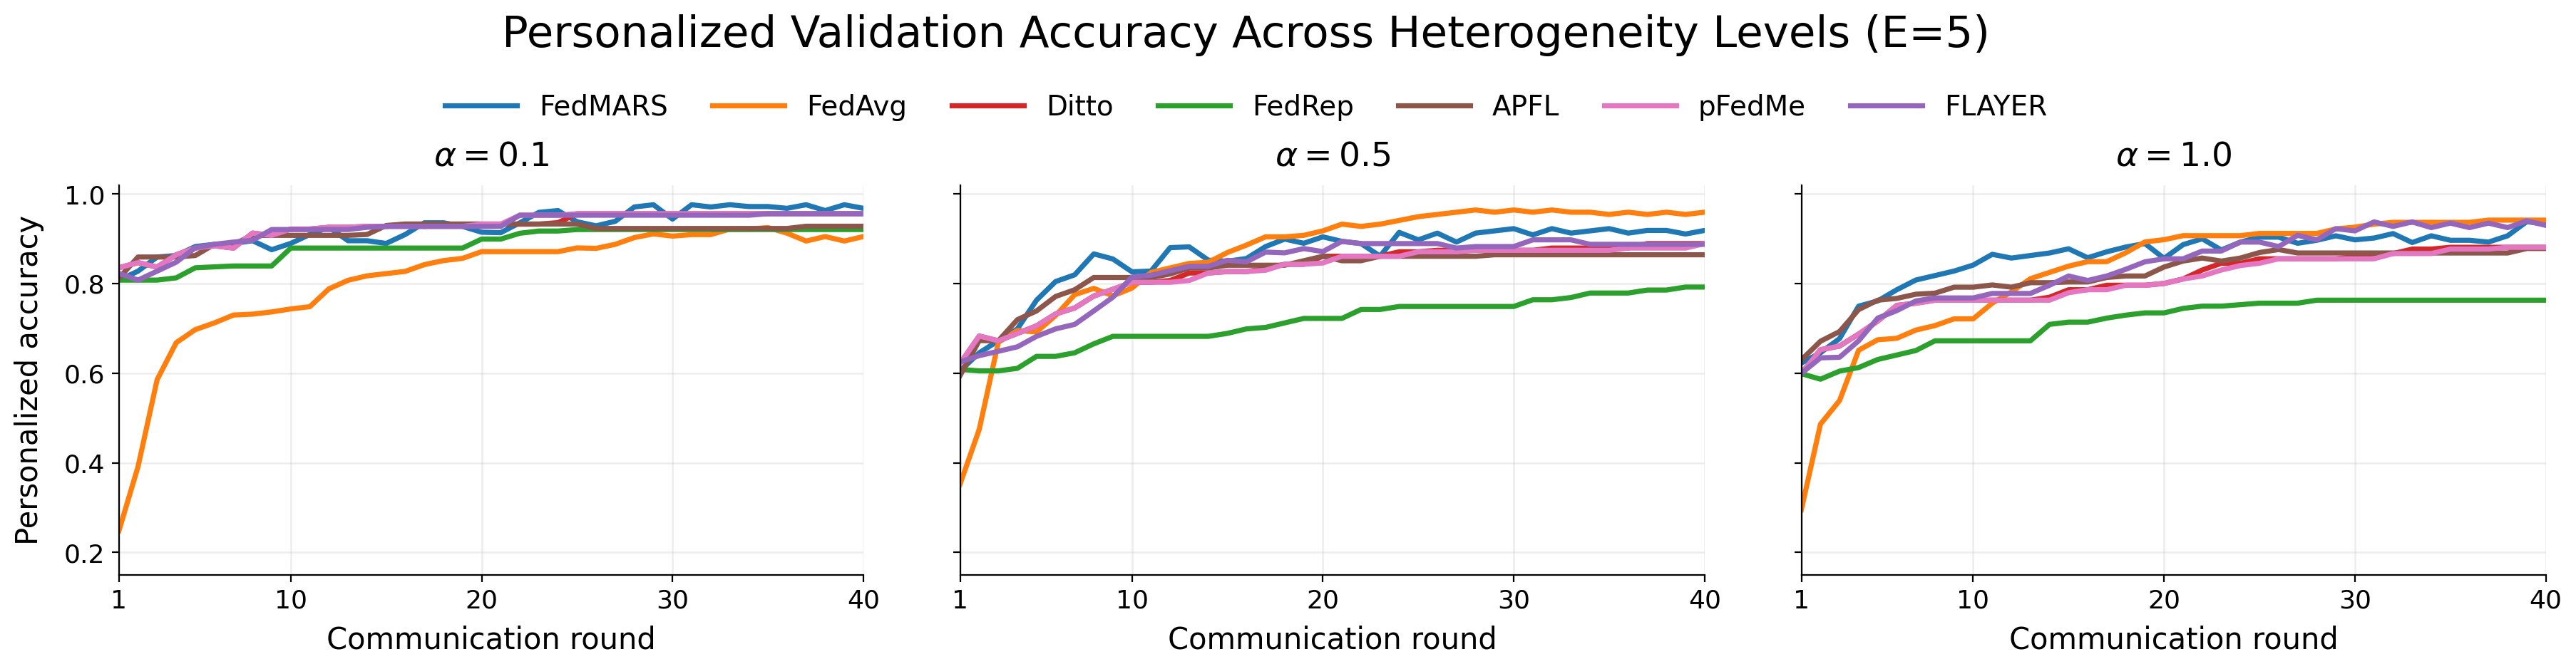

## Figure V2-2. Personalized validation accuracy under increasing local training (alpha=0.1)

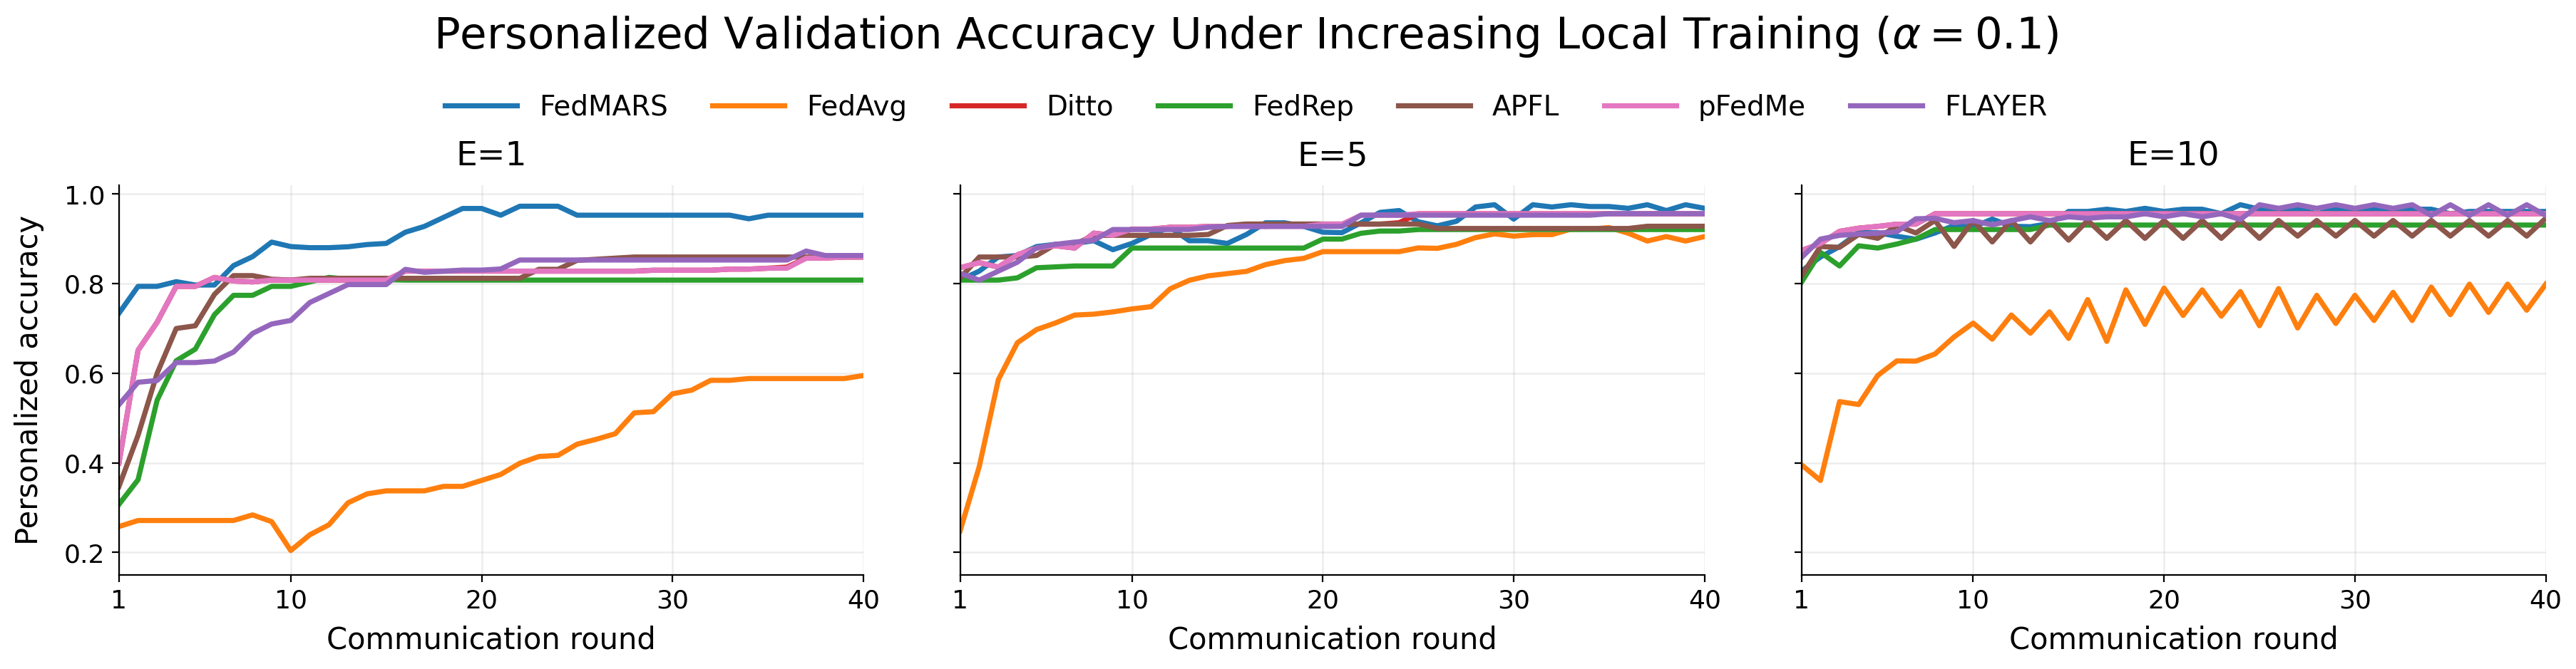

In [3]:
current_uci_id = 53

run_df, curve_df, summary_df, curve_mean_df, dataset_info = run_validation2(current_uci_id)

summary_for_save = summary_df.copy()
summary_for_save.insert(0, "uci_id", current_uci_id)
summary_for_save.insert(1, "dataset_name", str(dataset_info.get("dataset_name", "Iris")))
_save_checkpoint(summary_for_save)

display(Markdown("# Validation 2 — Iris"))

display(Markdown("## Table V2-1. Personalized client-level performance"))
display(make_accuracy_table(summary_df))

display(Markdown(f"## Figure V2-1. Personalized validation accuracy across heterogeneity levels (E={FOCUS_LOCAL_EPOCH_FOR_HETEROGENEITY_FIG})"))
plot_heterogeneity_personalized_accuracy(curve_mean_df, fixed_local_epochs=FOCUS_LOCAL_EPOCH_FOR_HETEROGENEITY_FIG)

display(Markdown(f"## Figure V2-2. Personalized validation accuracy under increasing local training (alpha={FOCUS_ALPHA_FOR_LOCAL_TRAINING_FIG})"))
plot_local_training_personalized_accuracy(curve_mean_df, fixed_alpha=FOCUS_ALPHA_FOR_LOCAL_TRAINING_FIG)
